In [14]:
import zipfile
import os

In [3]:
# Unzip the dataset
with zipfile.ZipFile('keratoconus.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

In [4]:
# This identifies the correct folder path for training
# Usually, it looks like 'dataset/Independent Test Set/Independent Test Set'
data_path = 'dataset/Independent Test Set/Independent Test Set'
print("Folders found:", os.listdir(data_path))

Folders found: ['Suspect', 'Keratoconus', 'Normal']


In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [6]:
# 1. IMAGE PREPARATION
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 840 images belonging to 3 classes.
Found 210 images belonging to 3 classes.


In [7]:
# 2. THE MODEL (The AI Brain)
# We use a pre-trained base and add our custom 'Eye Expert' layer on top
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Prevents the AI from 'memorizing' instead of 'learning'
    layers.Dense(3, activation='softmax') # 3 outputs: Normal, Suspect, Keratoconus
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# 3. TRAINING
print("Starting training...")
model.fit(train_gen, validation_data=val_gen, epochs=10)

Starting training...
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.4893 - loss: 1.0933 - val_accuracy: 0.6143 - val_loss: 0.8175
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6369 - loss: 0.7531 - val_accuracy: 0.6048 - val_loss: 0.7729
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6929 - loss: 0.6785 - val_accuracy: 0.6857 - val_loss: 0.6580
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7321 - loss: 0.6057 - val_accuracy: 0.6476 - val_loss: 0.6636
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7452 - loss: 0.5786 - val_accuracy: 0.7000 - val_loss: 0.6169
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7524 - loss: 0.5328 - val_accuracy: 0.6429 - val_loss: 0.6994
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7845 - loss: 0.4929 - val_accuracy: 0.6667 - val_loss: 0.7129
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8048 - loss: 0.4644 - val_

In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: Keratoconus (90.89% confidence)


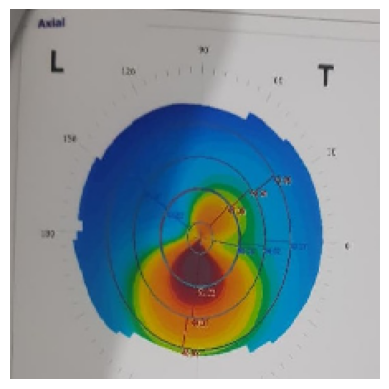

In [18]:
def predict_eye_issue(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    classes = list(train_gen.class_indices.keys()) # ['Keratoconus', 'Normal', 'Suspect']

    result = classes[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    print(f"Prediction: {result} ({confidence:.2f}% confidence)")
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Replace this with the filename of your uploaded eye report
predict_eye_issue('/content/WhatsApp Image 2026-04-16 at 21.50.43.jpeg')